<a href="https://colab.research.google.com/github/shadowBit01/energy-consumption-prediction/blob/main/Energy_Usage_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Energy_consumption.csv')

df = df.dropna()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

df = df.drop(['Timestamp', 'DayOfWeek'], axis=1)

df.head()

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,EnergyConsumption,hour,month,day_of_week
0,25.139433,43.431581,1565.693999,5,On,Off,2.774699,No,75.364373,0,1,5
1,27.731651,54.225919,1411.064918,1,On,On,21.831384,No,83.401855,1,1,5
2,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,No,78.270888,2,1,5
3,20.080469,50.371637,1452.316318,1,Off,On,8.623447,No,56.519850,3,1,5
4,23.097359,51.401421,1094.130359,9,On,Off,3.071969,No,70.811732,4,1,5


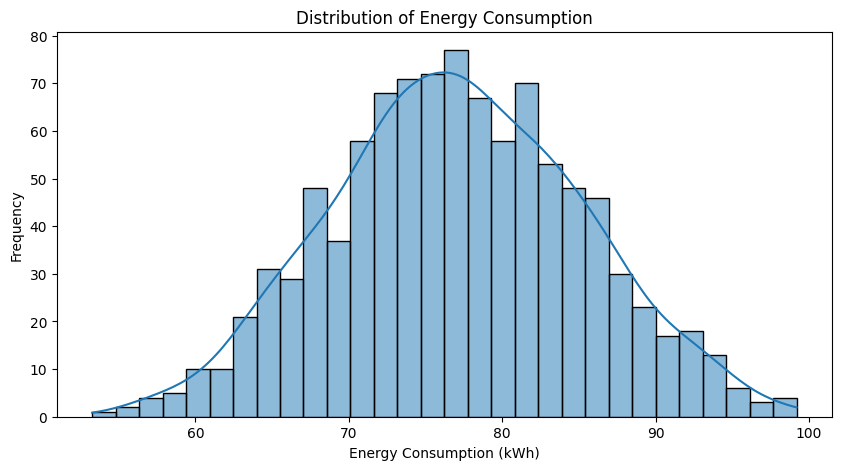

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['EnergyConsumption'], kde=True, bins=30)
plt.title('Distribution of Energy Consumption')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

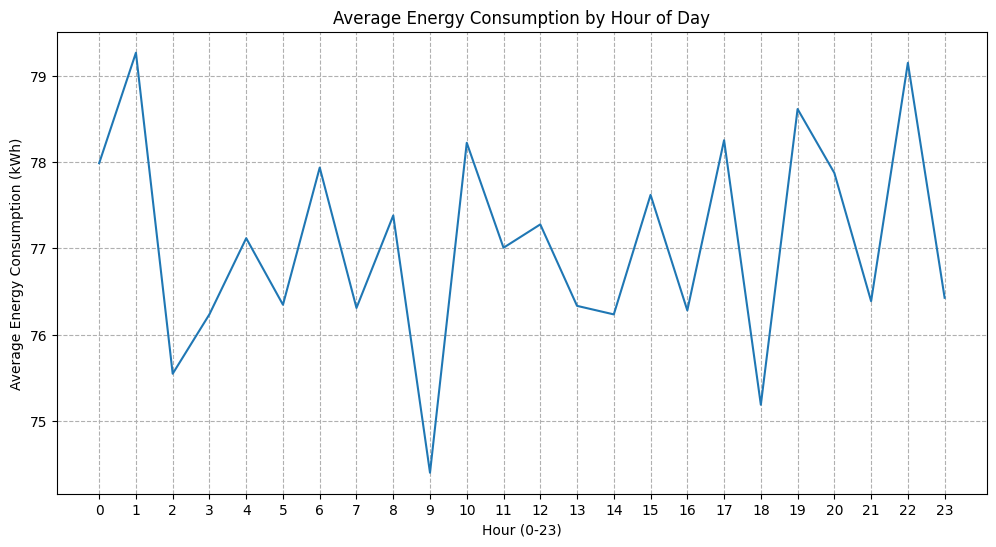

In [19]:
plt.figure(figsize=(12, 6))
df.groupby('hour')['EnergyConsumption'].mean().plot()
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average Energy Consumption (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--')
plt.show()

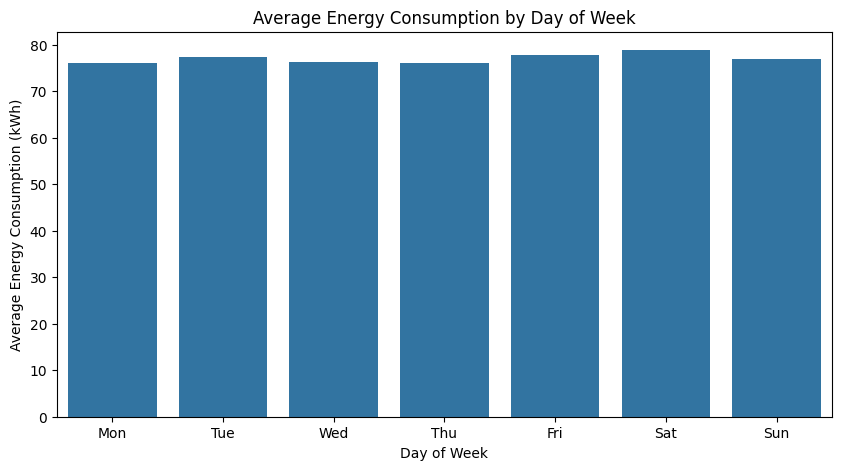

In [20]:
plt.figure(figsize=(10, 5))
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
day_data = df.groupby('day_of_week')['EnergyConsumption'].mean().reset_index()
day_data['day_name'] = day_data['day_of_week'].map(day_map)

sns.barplot(data=day_data, x='day_name', y='EnergyConsumption', order=day_map.values())
plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Consumption (kWh)')
plt.show()

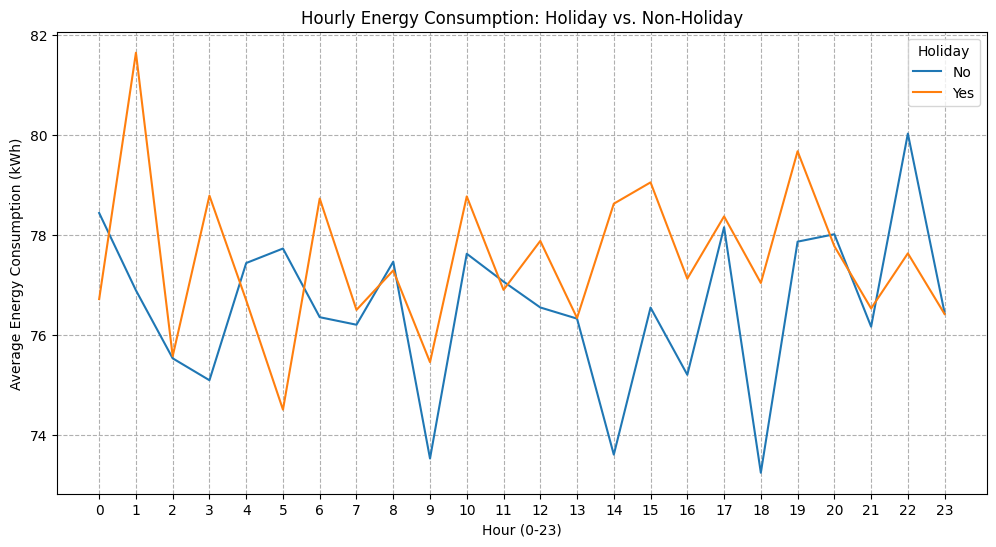

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='EnergyConsumption', hue='Holiday', errorbar=None)
plt.title('Hourly Energy Consumption: Holiday vs. Non-Holiday')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average Energy Consumption (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--')
plt.show()



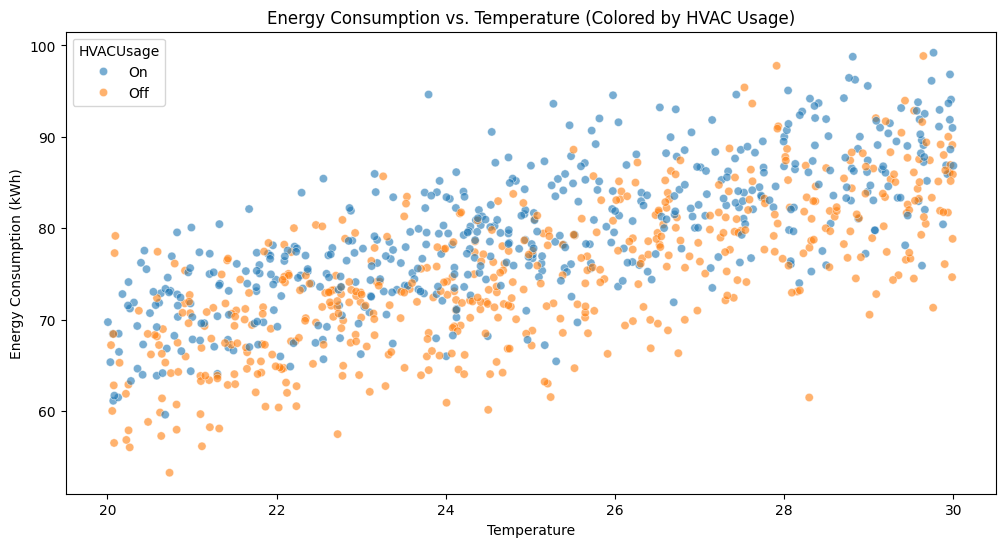

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Temperature', y='EnergyConsumption', hue='HVACUsage', alpha=0.6)
plt.title('Energy Consumption vs. Temperature (Colored by HVAC Usage)')
plt.xlabel('Temperature')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

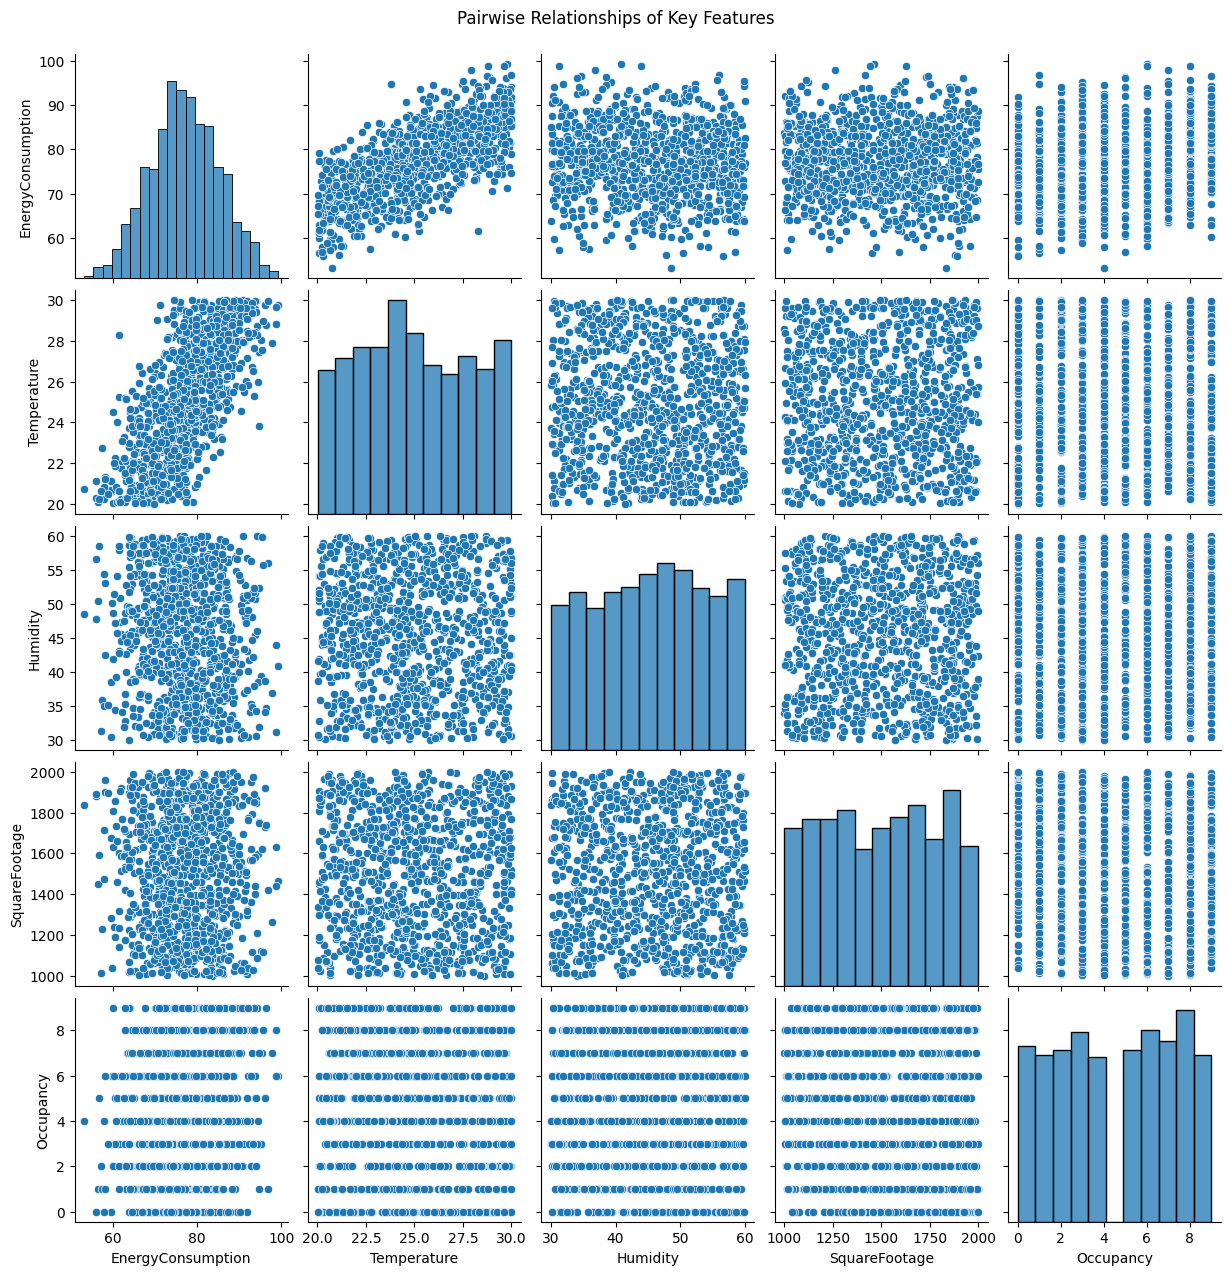

In [23]:
pairplot_cols = ['EnergyConsumption', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy']

sns.pairplot(df[pairplot_cols])
plt.suptitle('Pairwise Relationships of Key Features', y=1.02)
plt.show()

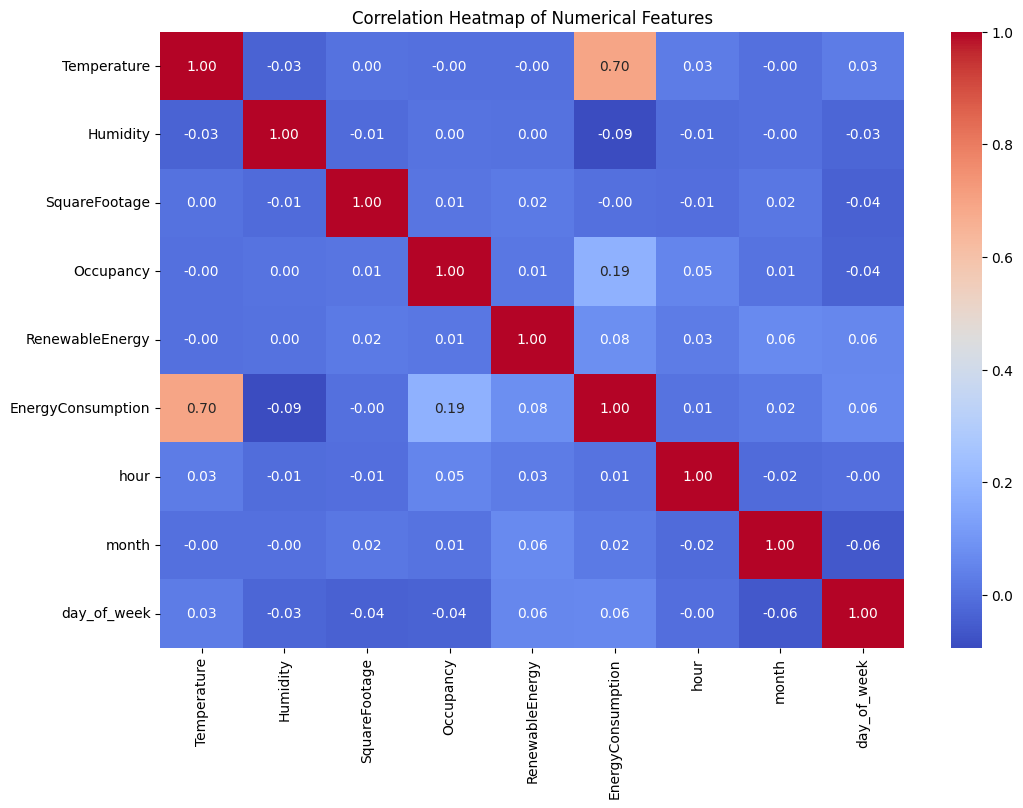

In [24]:
plt.figure(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

target_column = 'EnergyConsumption'
y = df[target_column]
X = df.drop(target_column, axis=1)

categorical_features = ['HVACUsage', 'LightingUsage', 'Holiday']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 11)
Testing set shape: (200, 11)


In [26]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LinearRegression())])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Temperature', 'Humidity',
                                                   'SquareFootage', 'Occupancy',
                                                   'RenewableEnergy', 'hour',
                                                   'month', 'day_of_week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['HVACUsage', 'LightingUsage',
                                                   'Holiday'])])),
                ('model', LinearRegression())])

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', GradientBoostingRegressor(random_state=42))])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.1, 0.05],
    'model__max_depth': [3, 5]
}

grid_search = GridSearchCV(gb_pipeline, param_grid, cv=3,
                           scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")

best_gb_model = grid_search.best_estimator_

Best parameters found: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


In [28]:
lr_preds = lr_pipeline.predict(X_test)
gb_preds = best_gb_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

print(f"Linear Regression Model RMSE: {lr_rmse:.4f}")
print(f"TUNED Gradient Boosting Model RMSE: {gb_rmse:.4f}")

lr_r2 = r2_score(y_test, lr_preds)
gb_r2 = r2_score(y_test, gb_preds)

print(f"\nLinear Regression R-squared: {lr_r2:.4f}")
print(f"TUNED Gradient Boosting R-squared: {gb_r2:.4f}")

Linear Regression Model RMSE: 5.1342
TUNED Gradient Boosting Model RMSE: 5.4473

Linear Regression R-squared: 0.5976
TUNED Gradient Boosting R-squared: 0.5470
